### Introduction (1p)

Defence spending has become one of the most debated topics in transatlantic politics. NATO members agreed to spend at least 2% of their GDP on defence, yet this target has been consistently missed by many member states. At the same time, the nature of modern militaries is changing — some countries maintain large armed forces while others invest in smaller, more technologically advanced forces.
This notebook analyses two indicators across all 32 NATO member states from 1990 to 2024:

- Military expenditure as % of GDP — to assess compliance with the 2% target
- Armed forces personnel as % of total workforce — to understand how the size of NATO forces has changed over time

Using data retrieved from the World Bank Open Data API, this project aims to answer the following questions:

- Have NATO members historically met the 2% GDP defence spending target, and who are the best and worst performers in 2024?
- Which countries show a consistent upward or downward trend in defence spending over the full period?
- Is there a relationship between how much a country spends on defence and the size of its armed forces?

### Documentation (0.5p)

___NATO Military Expenditure Analysis (1990–2024)___

This notebook analyses military expenditure and armed forces personnel across all the 32 NATO member states using data retrieved from the World Bank Open Data API. No API key is required.

_How to run this notebook_

Make sure the following Python libraries are installed:
- requests
- pandas
- matplotlib
- seaborn
- scipy

Install any missing libraries with: pip install requests pandas matplotlib seaborn scipy

Run the cells from top to bottom in order.

The notebook will automatically fetch data from the World Bank API. If you do not have internet access, use the commented-out import cells to load the saved CSV files instead.

_Data sources_

Military expenditure (% of GDP): World Bank indicator MS.MIL.XPND.GD.ZS
Armed forces personnel (% of total labor force): World Bank indicator MS.MIL.TOTL.TF.ZS

### An embedded image that describes visually the data pipeline and what happens in the notebook. (0.5p)

![Pipeline](pipeline.png)

In [1]:
from dotenv import load_dotenv
import os
import requests

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

### Data extraction (1p) with a part where the Notebook connects to an API for collecting data as the primary data source (2p)

Instructions: A component where data is extracted from some data source and/or loaded onto the Jupyter Notebook. The raw data needs to also be exported at this point and saved to the repository as a .csv or .json file, so that a reviewer can run and test the code with the saved data without needing an API key or manually loading the data from the source. E.g. have a cell where the data is exported, and a commented out code cell where the saved data can be imported.

In [2]:
#CODE: Import Armed forces personnel (% of total labor force) with the World Bank API
url_personnel ='https://api.worldbank.org/v2/country/all/indicator/MS.MIL.TOTL.TF.ZS?format=json&per_page=10000&date=1990:2024'

request_personnel = requests.get(url_personnel)
print("Status code is")
print(request_personnel.status_code)

personnel = request_personnel.json()
print(len(personnel))
print(personnel[0])

personnel_df =pd.DataFrame(personnel[1])
display(personnel_df.head())

Status code is
200
2
{'page': 1, 'pages': 1, 'per_page': 10000, 'total': 9310, 'sourceid': '2', 'lastupdated': '2026-04-08'}


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,NaN,,,1
1,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,NaN,,,1
2,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,NaN,,,1
3,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,NaN,,,1
4,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,0.448188,,,1


In [3]:
#CODE export and save to the repository as a .csv file
personnel_df.to_csv('personnel_df.csv', index=False) 

#if needed, import the data with this line of code:
#personnel_df=pd.read_csv("personnel_df.csv")

In [4]:
#CODE import Military expenditure (% of GDP) with the World Bank API

url_expenditure ='https://api.worldbank.org/v2/country/all/indicator/MS.MIL.XPND.GD.ZS?format=json&per_page=10000&date=1990:2024'

request_expenditure = requests.get(url_expenditure)
print("Status code is")
print(request_expenditure.status_code)

expenditure = request_expenditure.json()
print(len(expenditure))
print(expenditure[0])

expenditure_df =pd.DataFrame(expenditure[1])
display(expenditure_df.head())

Status code is
200
2
{'page': 1, 'pages': 1, 'per_page': 10000, 'total': 9310, 'sourceid': '2', 'lastupdated': '2026-04-08'}


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,0.976005,,,1
1,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.044194,,,1
2,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1.118534,,,1
3,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1.145973,,,1
4,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,1.158166,,,1


In [5]:
#CODE export and save to the repository as a .csv file
#export and save to the repository as a .csv file
expenditure_df.to_csv('expenditure_df.csv', index=False) 

#if needed, import the data with this line of code:
#expenditure_df=pd.read_csv("expenditure_df.csv")

### A component where the loaded data is cleaned and transformed (1p)

I have two problems with the data: 
1) The indicator and country columns in the dataframes are dictionaries inside the columns. The text values need to extracted
2) The datasets contain all the countries in the world, not just NATO members. These need to be filtered to the 32 NATO members

Furthermore, the two datasets need to be merged and checked for missing values

In [6]:
#CODE: DATA CLEANING AND TRANSFORMATION
#expenditure_df
display(expenditure_df)
#The indicator and country columns in the dataframe are dictionaries inside the columns. The text values need to extracted.

expenditure_df['indicator']= expenditure_df['indicator'].apply(lambda x: x['value'])
expenditure_df['country'] = expenditure_df['country'].apply(lambda x: x['value'])

#remove indicator column because there is only one value
expenditure_df=expenditure_df.drop(["indicator"], axis=1)

#remove other redundant columns

print(expenditure_df['obs_status'].unique())
print(expenditure_df['unit'].unique())
print(expenditure_df['decimal'].unique())

expenditure_df=expenditure_df.drop(["obs_status"], axis=1)
expenditure_df=expenditure_df.drop(["unit"], axis=1)
expenditure_df=expenditure_df.drop(["decimal"], axis=1)

display(expenditure_df)

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,0.976005,,,1
1,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.044194,,,1
2,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1.118534,,,1
3,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1.145973,,,1
4,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,1.158166,,,1
...,...,...,...,...,...,...,...,...
9305,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1994,3.114713,,,1
9306,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1993,3.300304,,,1
9307,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1992,3.802772,,,1
9308,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1991,3.979365,,,1


['']
['']
[1]


,country,countryiso3code,date,value
0,Africa Eastern and Southern,AFE,2024,0.976005
1,Africa Eastern and Southern,AFE,2023,1.044194
2,Africa Eastern and Southern,AFE,2022,1.118534
3,Africa Eastern and Southern,AFE,2021,1.145973
4,Africa Eastern and Southern,AFE,2020,1.158166
...,...,...,...,...
9305,Zimbabwe,ZWE,1994,3.114713
9306,Zimbabwe,ZWE,1993,3.300304
9307,Zimbabwe,ZWE,1992,3.802772
9308,Zimbabwe,ZWE,1991,3.979365


In [7]:
#CODE: DATA CLEANING AND TRANSFORMATION
#personnel_df
#The indicator and country columns in the dataframe are dictionaries inside the columns. The text values need to extracted.

personnel_df['indicator']= personnel_df['indicator'].apply(lambda x: x['value'])
personnel_df['country'] = personnel_df['country'].apply(lambda x: x['value'])

#remove indicator column because there is only one value
personnel_df=personnel_df.drop(["indicator"], axis=1)
display(personnel_df)

#remove other redundant columns

print(personnel_df['obs_status'].unique())
print(personnel_df['unit'].unique())
print(personnel_df['decimal'].unique())

personnel_df=personnel_df.drop(["obs_status"], axis=1)
personnel_df=personnel_df.drop(["unit"], axis=1)
personnel_df=personnel_df.drop(["decimal"], axis=1)

display(personnel_df)

,country,countryiso3code,date,value,unit,obs_status,decimal
0,Africa Eastern and Southern,AFE,2024,NaN,,,1
1,Africa Eastern and Southern,AFE,2023,NaN,,,1
2,Africa Eastern and Southern,AFE,2022,NaN,,,1
3,Africa Eastern and Southern,AFE,2021,NaN,,,1
4,Africa Eastern and Southern,AFE,2020,0.448188,,,1
...,...,...,...,...,...,...,...
9305,Zimbabwe,ZWE,1994,1.107998,,,1
9306,Zimbabwe,ZWE,1993,1.246526,,,1
9307,Zimbabwe,ZWE,1992,1.259600,,,1
9308,Zimbabwe,ZWE,1991,1.211387,,,1


['']
['']
[1]


,country,countryiso3code,date,value
0,Africa Eastern and Southern,AFE,2024,NaN
1,Africa Eastern and Southern,AFE,2023,NaN
2,Africa Eastern and Southern,AFE,2022,NaN
3,Africa Eastern and Southern,AFE,2021,NaN
4,Africa Eastern and Southern,AFE,2020,0.448188
...,...,...,...,...
9305,Zimbabwe,ZWE,1994,1.107998
9306,Zimbabwe,ZWE,1993,1.246526
9307,Zimbabwe,ZWE,1992,1.259600
9308,Zimbabwe,ZWE,1991,1.211387


In [8]:
#Filter NATO members. 

# A list of NATO Country members ISO codes
nato_iso3 = [
    'ALB', 'BEL', 'BGR', 'CAN', 'HRV', 'CZE', 'DNK', 'EST', 'FIN', 'FRA',
    'DEU', 'GRC', 'HUN', 'ISL', 'ITA', 'LVA', 'LTU', 'LUX', 'MNE', 'NLD',
    'MKD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP', 'SWE', 'TUR',
    'GBR', 'USA'
]

personnel_NATO=personnel_df[(personnel_df['countryiso3code'].isin(nato_iso3)) ]
expenditure_NATO=expenditure_df[(expenditure_df['countryiso3code'].isin(nato_iso3)) ]

display(personnel_NATO.head())
display(expenditure_NATO.head())


,country,countryiso3code,date,value
1750,Albania,ALB,2024,NaN
1751,Albania,ALB,2023,NaN
1752,Albania,ALB,2022,NaN
1753,Albania,ALB,2021,NaN
1754,Albania,ALB,2020,0.64617


,country,countryiso3code,date,value
1750,Albania,ALB,2024,2.037862
1751,Albania,ALB,2023,1.740733
1752,Albania,ALB,2022,1.208789
1753,Albania,ALB,2021,1.242988
1754,Albania,ALB,2020,1.295836


In [9]:
#Merge the two dataframes

df= pd.merge(personnel_NATO, expenditure_NATO, on=("country","countryiso3code", "date"))


df= df.rename(columns={"value_x": "personnel", "value_y": "expenditure"})

display(df)


,country,countryiso3code,date,personnel,expenditure
0,Albania,ALB,2024,NaN,2.037862
1,Albania,ALB,2023,NaN,1.740733
2,Albania,ALB,2022,NaN,1.208789
3,Albania,ALB,2021,NaN,1.242988
4,Albania,ALB,2020,0.646170,1.295836
...,...,...,...,...,...
1115,United States,USA,1994,1.277753,4.215265
1116,United States,USA,1993,1.376005,4.604350
1117,United States,USA,1992,1.467291,4.970467
1118,United States,USA,1991,1.646722,4.883429


In [10]:
#Check for missing values
df.isna().sum()

#I decided to keep the missing values and deal with them when I analyse the data

country              0
countryiso3code      0
date                 0
personnel          172
expenditure         75
dtype: int64

### Data Analysis (2p)

A component where the cleaned data is analyzed visually and quantitatively (e.g. using statistics or machine learning)

In [11]:
#Basic statistics
df.describe()

,personnel,expenditure
count,948.000000,1045.000000
mean,1.401011,1.840523
std,1.084763,0.995532
min,0.000000,0.358492
25%,0.709071,1.291808
50%,1.064266,1.609071
75%,1.704971,2.050324
max,7.197524,11.148177


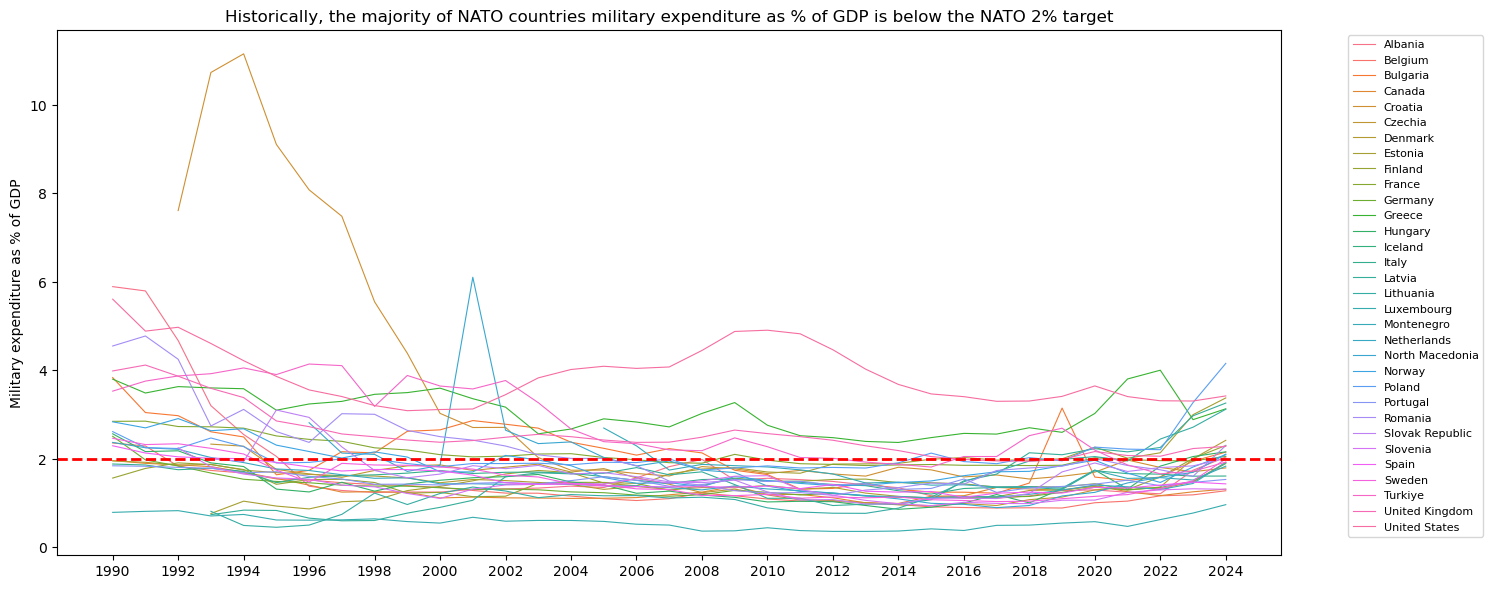

In [12]:
#Visual analysis of the data

# Line chart — spending over time for NATO members with 2% threshold line

plt.figure(figsize=(15, 6))
ax = sns.lineplot(data=df, x="date", y="expenditure", hue="country", linewidth=0.8)
ax.axhline(y=2, linewidth=2, color='red', ls='--')
ax.invert_xaxis()
ax.set_xticks(df['date'].unique()[::2])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.title("Historically, the majority of NATO countries military expenditure as % of GDP is below the NATO 2% target")
plt.ylabel("Military expenditure as % of GDP")
plt.xlabel('')
plt.show()


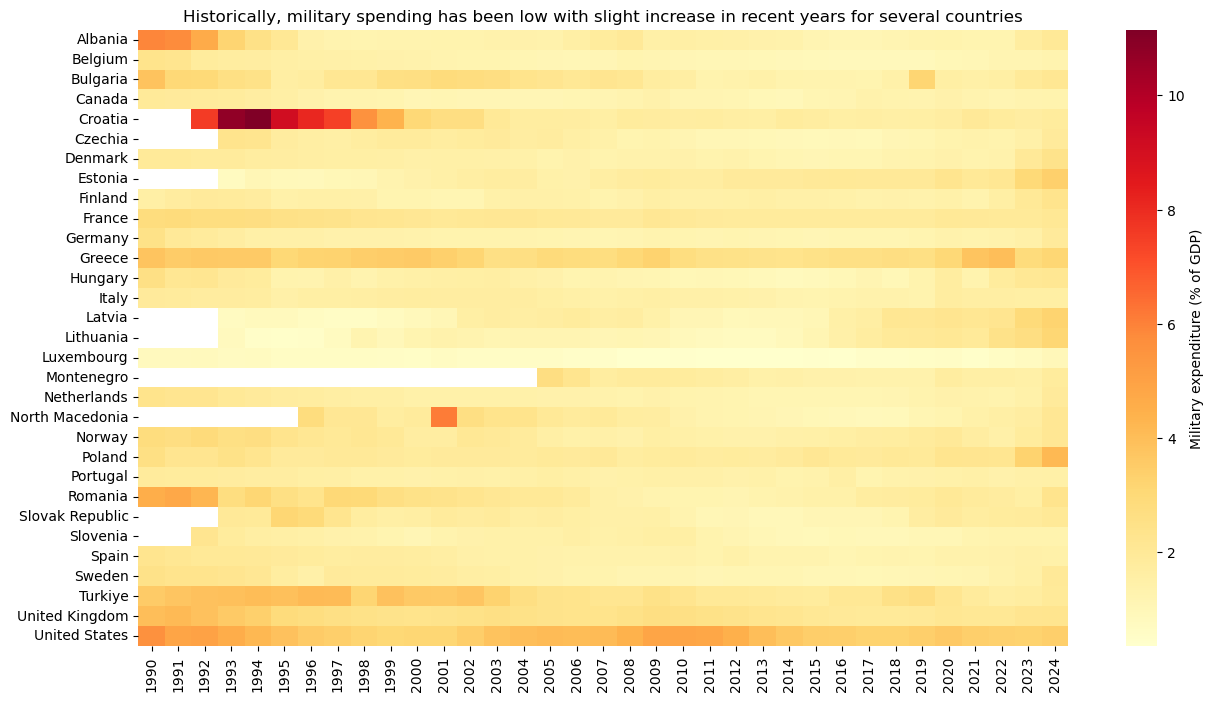

In [13]:
#Data visualisation: Heatmap for expenditute
df_pivot = df.pivot_table(index='country', columns='date', values='expenditure') #convert the dataframe to wide format
#display(df_pivot)

plt.figure(figsize=(15, 8))
sns.heatmap(df_pivot, cmap='YlOrRd', cbar_kws={'label': 'Military expenditure (% of GDP)'})
plt.title("Historically, military spending has been low with slight increase in recent years for several countries")
plt.ylabel('')
plt.xlabel('')
plt.show()



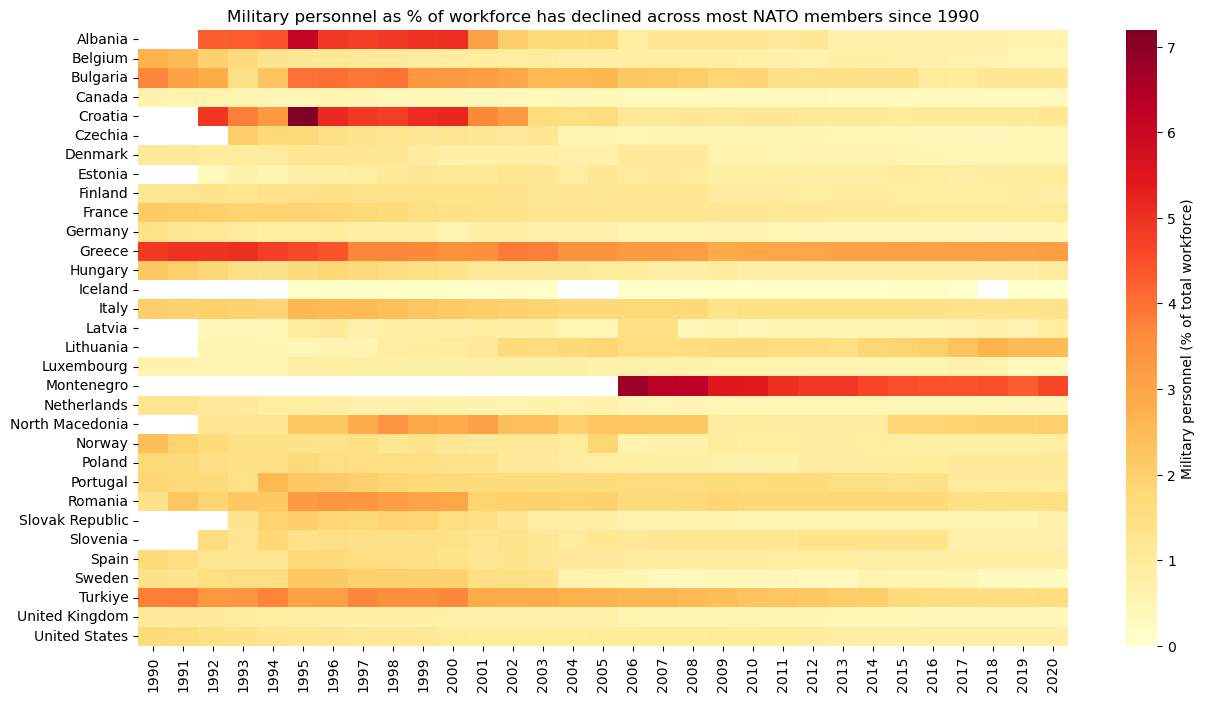

In [14]:
#Data visualisation: Heatmap for personnel
df_pivot_personnel = df.pivot_table(index='country', columns='date', values='personnel') #convert the dataframe to wide format
#display(df_pivot_personnel)

plt.figure(figsize=(15, 8))
sns.heatmap(df_pivot_personnel, cmap='YlOrRd', cbar_kws={'label': 'Military personnel (% of total workforce)'})
plt.title("Military personnel as % of workforce has declined across most NATO members since 1990")
plt.ylabel('')
plt.xlabel('')
plt.show()

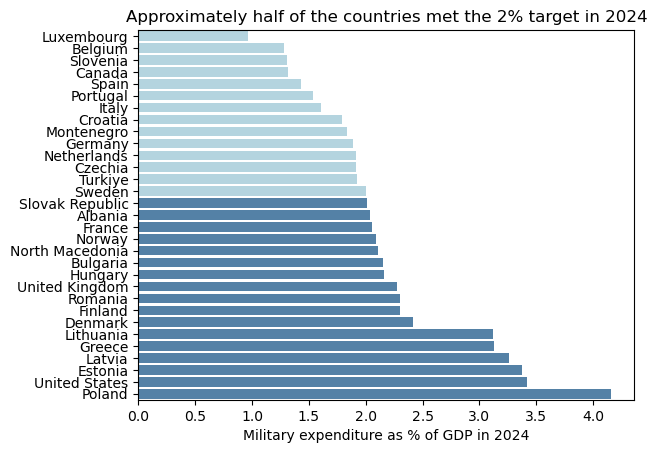

In [15]:
df_2024=df.loc[df['date'] == '2024']

df_2024=df_2024.sort_values(by=["expenditure"])
#df_2024.tail()
df_2024 = df_2024.dropna(subset=['expenditure'])

colors = ['steelblue' if x >= 2 else 'lightblue' for x in df_2024['expenditure']]
ax = sns.barplot(df_2024, x="expenditure", y="country", hue="country", palette=dict(zip(df_2024['country'], colors)), legend=False)
plt.title("Approximately half of the countries met the 2% target in 2024")
plt.ylabel('')
plt.xlabel("Military expenditure as % of GDP in 2024")
plt.show()

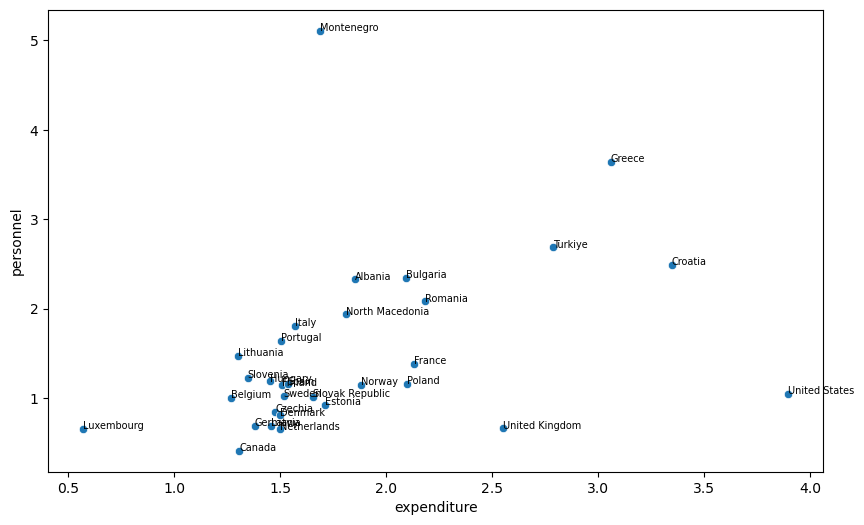

In [16]:
#Statistical analysis with visualisations

df.head()

df_avg = df.groupby('country')[['expenditure', 'personnel']].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=df_avg, x='expenditure', y='personnel')
for idx, row in df_avg.iterrows():
    ax.annotate(row['country'], (row['expenditure'], row['personnel']), fontsize=7)
plt.show()




In [17]:

# Correlation between expenditure and personnel
correlation = df[['expenditure', 'personnel']].corr()
print("\nCorrelation between military expenditure and personnel:")
display(correlation)


Correlation between military expenditure and personnel:


,expenditure,personnel
expenditure,1.000000,0.485028
personnel,0.485028,1.000000


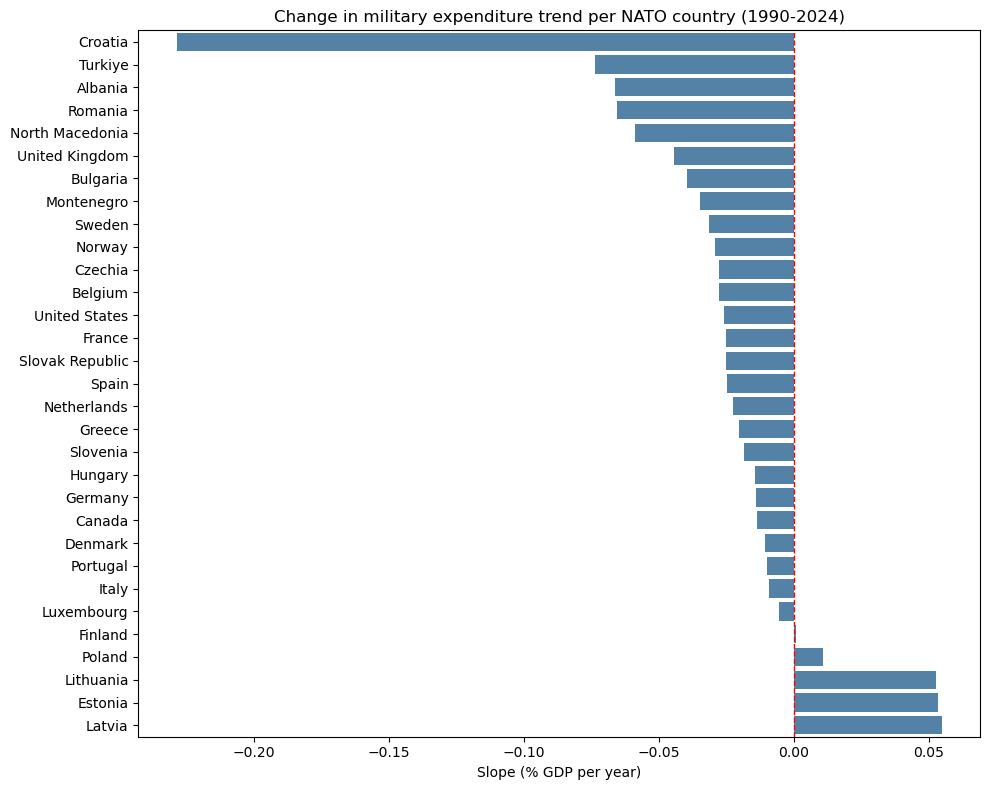

Regression slopes (expenditure trend per country):


,country,slope
4,Croatia,-0.228500
28,Turkiye,-0.073633
0,Albania,-0.066387
23,Romania,-0.065462
19,North Macedonia,-0.058821
29,United Kingdom,-0.044225
2,Bulgaria,-0.039587
17,Montenegro,-0.034574
27,Sweden,-0.031414
20,Norway,-0.029092


In [18]:
#Trend Analysis: Linear Regression of Military Expenditure per NATO Country (1990-2024)

slopes = []
for country, group in df.groupby('country'):
    group = group.dropna(subset=['expenditure'])
    if len(group) > 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(group['date'].astype(int), group['expenditure'])
        slopes.append({'country': country, 'slope': slope})

slopes_df = pd.DataFrame(slopes).sort_values('slope')

plt.figure(figsize=(10, 8))
ax = sns.barplot(slopes_df, x='slope', y='country', color='steelblue')
plt.axvline(x=0, color='red', linewidth=1, ls='--')
plt.title('Change in military expenditure trend per NATO country (1990-2024)')
plt.xlabel('Slope (% GDP per year)')
plt.ylabel('')
plt.tight_layout()
plt.show()


print("Regression slopes (expenditure trend per country):")
display(slopes_df)

In [19]:
df[df['expenditure'] == df['expenditure'].max()]

,country,countryiso3code,date,personnel,expenditure
170,Croatia,HRV,1994,3.315023,11.148177


### Data and results exportation (1p)

In [20]:
# Export results
slopes_df.to_csv('slopes.csv', index=False)
df_avg.to_csv('averages.csv', index=False)
df.to_csv('nato_military_data.csv', index=False)

### Cconclusions (1p)

This analysis examined military expenditure (% of GDP) and armed forces personnel (% of total workforce) across all 32 NATO member states from 1990 to 2024, using data from the World Bank API.

The descriptive statistics reveal that the average military expenditure across NATO members has historically been 1.84% of GDP, which is below the 2% target agreed upon by NATO members. Only the top quarter of country-year observations exceed the 2% threshold, suggesting that meeting the target has been the exception rather than the norm.

The most extreme value in the dataset is Croatia in 1994, which spent over 11% of GDP on defence during the Yugoslav Wars. This outlier is clearly visible in both the heatmap and the regression analysis, where Croatia shows the steepest downward trend of all members over the full period.

The linear regression analysis shows that only three countries; Poland, Lithuania, and Estonia show a consistently positive spending trend over the entire 1990-2024 period. All the three countries are bordering or near Russia, suggesting that geographic proximity to a perceived threat is a stronger driver of sustained defence investment than NATO membership alone.

The most recent data (2024) shows increased spending across several members, likely reflecting the impact of Russia's full-scale invasion of Ukraine in 2022. Poland leads all NATO members in 2024 with over 4% of GDP, followed by Estonia and Latvia. At the other end of the scale, Luxembourg and Belgium are the weakest performers, both spending well below 1.5% of GDP.

The moderate correlation (r = 0.485) between expenditure and personnel suggests that higher spending does not automatically mean larger forces. Countries such as the US maintain smaller but technologically advanced militaries, while Greece and Montenegro maintain relatively large armed forces despite moderate spending levels.

To conclude, the data shows that defence spending has been declining for most members since the Cold War, with a recent reversal driven primarily by Eastern European NATO members, which can be interpreted as a response to the Russian aggression.

### Statement of AI use

I used Claude (Anthropic) as a learning assistant throughout this project. Claude provided guidance, debugging advice, and explanations to help me develop the notebook independently. It did not generate ready-made code. 

More specifically, Claude was used to:

- Understand the structure of the API response and construct appropriate query URLs
- Debug errors during data fetching, cleaning, and visualisation
- Explain Python methods and concepts, particularly for pandas, seaborn, and scipy
- Suggest visualisation approaches and help refine chart appearance

All code was written and run by me in JupyterLab. 